In [1]:
from core import MClimate, GEFSLivePull
import matplotlib.pyplot as plt
import seaborn as sns
from gefsv12_retro_kerchunk import utils
import numpy as np
import xarray as xr
import bottleneck
import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cartopy.feature as cfeature
sns.set_theme(style="darkgrid", palette="deep",font_scale=1.3)

In [2]:
client = utils.start_dask_cluster(
    n_workers=6, threads_per_worker=4, memory_limit="4GiB"
)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 6
Total threads: 24,Total memory: 24.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:55319,Workers: 6
Dashboard: http://127.0.0.1:8787/status,Total threads: 24
Started: Just now,Total memory: 24.00 GiB
Comm: tcp://127.0.0.1:55349,Total threads: 4
Dashboard: http://127.0.0.1:55357/status,Memory: 4.00 GiB
Nanny: tcp://127.0.0.1:55322,


In [3]:
gefs = GEFSLivePull()
mc = MClimate()
gefs_l = gefs.gefs_live(ensemble=True)
gefs_r = mc.generate_mclimate()

File s3://noaa-gefs-pds/gefs.20241115/12/atmos/pgrb2sp25/gespr.t12z.pgrb2s.0p25.f003 written to C:\Users\TMAN1_~1\AppData\Local\Temp\tmpmw_mlugpgefs_rt_spr.json
File s3://noaa-gefs-pds/gefs.20241115/12/atmos/pgrb2sp25/geavg.t12z.pgrb2s.0p25.f003 written to C:\Users\TMAN1_~1\AppData\Local\Temp\tmpmw_mlugpgefs_rt_avg.json
File s3://noaa-gefs-pds/gefs.20241115/12/atmos/pgrb2sp25/gec00.t12z.pgrb2s.0p25.f003 written to C:\Users\TMAN1_~1\AppData\Local\Temp\tmpmw_mlugpgefs_rt_c00.json
File s3://noaa-gefs-pds/gefs.20241115/12/atmos/pgrb2sp25/gep01.t12z.pgrb2s.0p25.f003 written to C:\Users\TMAN1_~1\AppData\Local\Temp\tmpmw_mlugpgefs_rt_p01.json
File s3://noaa-gefs-pds/gefs.20241115/12/atmos/pgrb2sp25/gep02.t12z.pgrb2s.0p25.f003 written to C:\Users\TMAN1_~1\AppData\Local\Temp\tmpmw_mlugpgefs_rt_p02.json
File s3://noaa-gefs-pds/gefs.20241115/12/atmos/pgrb2sp25/gep03.t12z.pgrb2s.0p25.f003 written to C:\Users\TMAN1_~1\AppData\Local\Temp\tmpmw_mlugpgefs_rt_p03.json
File s3://noaa-gefs-pds/gefs.20241

x:\anaconda3\envs\espr\Lib\site-packages\kerchunk\combine.py:379: UserWarning: Concatenated coordinate 'valid_time' contains less than expectednumber of values across the datasets: [1731682800]
  warnings.warn(
x:\anaconda3\envs\espr\Lib\site-packages\kerchunk\combine.py:379: UserWarning: Concatenated coordinate 'valid_time' contains less than expectednumber of values across the datasets: [1731682800]
  warnings.warn(
x:\anaconda3\envs\espr\Lib\site-packages\kerchunk\combine.py:379: UserWarning: Concatenated coordinate 'valid_time' contains less than expectednumber of values across the datasets: [1731682800]
  warnings.warn(
x:\anaconda3\envs\espr\Lib\site-packages\kerchunk\combine.py:379: UserWarning: Concatenated coordinate 'step' contains less than expectednumber of values across the datasets: [3]
  warnings.warn(


In [5]:
gefs_r_std = gefs_r.std(dim="number")
gefs_r_mean = gefs_r.mean(dim="number")

In [53]:
def combine_fcast_and_mcli(fcast, mcli):
    big_da = xr.concat([mcli['msl'],fcast['prmsl']],dim='valid_time')
    # percentile = bottleneck.rankdata(big_da,axis=0)/len(big_da['valid_time'])
    return big_da

In [ ]:
percentile_ranked = combine_fcast_and_mcli(gefs_l.geavg.drop_vars(['meanSea','time']),gefs_r_mean.squeeze())

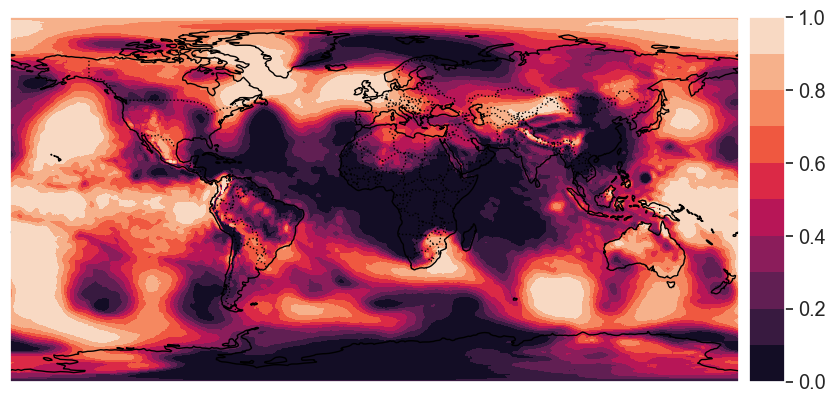

In [72]:
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': ccrs.PlateCarree()})
# Add coastlines and borders for better visualization
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
pcm = ax.contourf(gefs_l.gespr['longitude'], 
gefs_l.gespr['latitude'], 
percentile_ranked[-1], 
transform=ccrs.PlateCarree(),levels=np.linspace(0,1,11)
)
divider = make_axes_locatable(ax)
ax_cb = divider.new_horizontal(size="5%", pad=0.1, axes_class=plt.Axes)
fig.add_axes(ax_cb)
plt.colorbar(pcm, cax=ax_cb)
plt.show()

In [5]:
bins = np.arange(0,200,4)

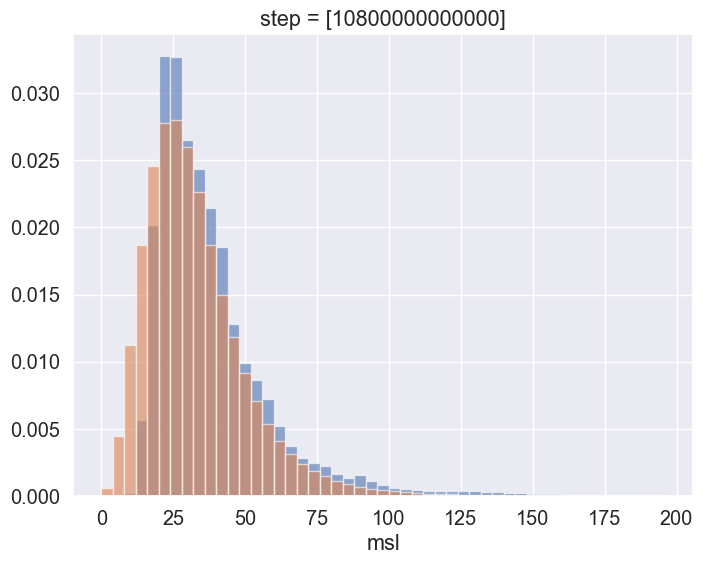

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
gefs_l.gespr['prmsl'].plot.hist(bins=bins,ax=ax,alpha=0.6,density=True,label='GEFS-L')
gefs_r_std['msl'].plot.hist(bins=bins, ax=ax, alpha=0.6, density=True, label='GEFS-R')
plt.show()

In [6]:
quantiles = np.linspace(0, 1, 100)
gefs_r_quantiles = np.quantile(gefs_r_std['msl'], quantiles)
gefs_l_quantiles = np.quantile(gefs_l.gespr['prmsl'], quantiles)

2024-11-07 17:01:25,182 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:57474 (pid=7740) exceeded 95% memory budget. Restarting...
2024-11-07 17:01:25,373 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:57474' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('moment_chunk-99817184255e217b798c224cff211852', 1, 0, 58, 0, 0), ('moment_chunk-99817184255e217b798c224cff211852', 1, 0, 57, 0, 0), ('moment_chunk-99817184255e217b798c224cff211852', 2, 0, 57, 0, 0), ('moment_chunk-99817184255e217b798c224cff211852', 0, 0, 57, 0, 0), ('moment_chunk-99817184255e217b798c224cff211852', 2, 0, 58, 0, 0), ('moment_chunk-99817184255e217b798c224cff211852', 0, 0, 54, 0, 0), ('moment_chunk-99817184255e217b798c224cff211852', 0, 0, 58, 0, 0)} (stimulus_id='handle-worker-cleanup-1731016885.3729165')
2024-11-07 17:01:26,649 - distributed.nanny - WARNING - Restarting worker


In [7]:
mapped_gefs_l_data = np.interp(gefs_l.gespr['prmsl'].values.flatten(), gefs_l_quantiles, gefs_r_quantiles)

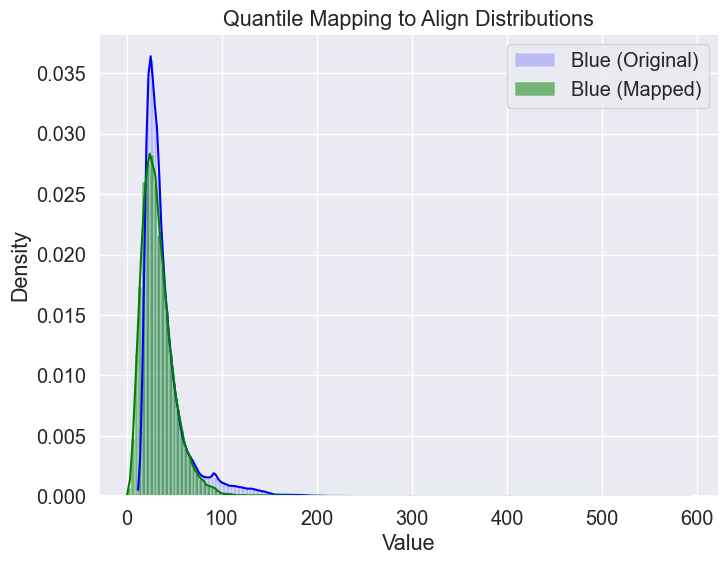

In [8]:
# Step 2: Map blue data to orange distribution using quantiles
fig, ax = plt.subplots(figsize=(8,6))
# Plot the original and mapped distributions
# sns.histplot(gefs_r_std['msl'].values.flatten(), ax=ax, bins=bins, kde=True, color="orange", stat="density", label="Orange (Target)")
sns.histplot(gefs_l.gespr['prmsl'].values.flatten(), ax=ax, bins=bins, kde=True, color="blue", alpha=0.2, stat="density", label="Blue (Original)")
sns.histplot(mapped_gefs_l_data, ax=ax, bins=bins, kde=True, color="green", alpha=0.5, stat="density", label="Blue (Mapped)")

plt.legend()
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Quantile Mapping to Align Distributions")
plt.show()


In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Reshape the mapped data to the original shape
reshaped_data = mapped_gefs_l_data.reshape(gefs_l.gespr['prmsl'].shape)

# Create a figure and axis with Cartopy projection
fig, ax = plt.subplots(2,2,figsize=(30, 15), subplot_kw={'projection': ccrs.PlateCarree()})
ax = ax.flatten()

# Add coastlines and borders for better visualization
ax[0].coastlines()
ax[0].add_feature(cfeature.BORDERS, linestyle=':')
# Add coastlines and borders for better visualization
ax[1].coastlines()
ax[1].add_feature(cfeature.BORDERS, linestyle=':')
# Plot the data
contour1 = ax[0].contourf(gefs_l.gespr['longitude'], 
gefs_l.gespr['latitude'], 
reshaped_data[0, :, :], 
transform=ccrs.PlateCarree(), 
cmap='viridis',
levels=np.linspace(0,400,11))

emean_contour = ax[0].contour(gefs_l.gespr['longitude'], 
gefs_l.gespr['latitude'], 
gefs_l.geavg['prmsl'].squeeze()/100, 
transform=ccrs.PlateCarree(), 
colors='gray', 
levels=np.arange(950,1050,4),linewidths=0.25)

ax[0].set_title('Quantile Mapped GEFS-L MSL Spread')
contour2 = ax[1].contourf(gefs_l.gespr['longitude'], 
gefs_l.gespr['latitude'], 
gefs_l.gespr['prmsl'].squeeze(), 
transform=ccrs.PlateCarree(), 
cmap='viridis',
levels=np.linspace(0,400,11)
)
emean_contour = ax[1].contour(gefs_l.gespr['longitude'], 
gefs_l.gespr['latitude'], 
gefs_l.geavg['prmsl'].squeeze()/100, 
transform=ccrs.PlateCarree(), 
colors='gray', 
levels=np.arange(950,1050,4),linewidths=0.25)
ax[1].set_title('Original GEFS-L MSL Spread')
# Add a colorbar
cbar1 = plt.colorbar(contour1, ax=ax[0], orientation='vertical', pad=0.05,ticks=[0,100,200,300,400])
cbar2 = plt.colorbar(contour2, ax=ax[1], orientation='vertical', pad=0.05,ticks=[0,100,200,300,400])

cbar1.set_label('Mapped Pressure Values')
cbar2.set_label('Mapped Pressure Values')
plt.show()

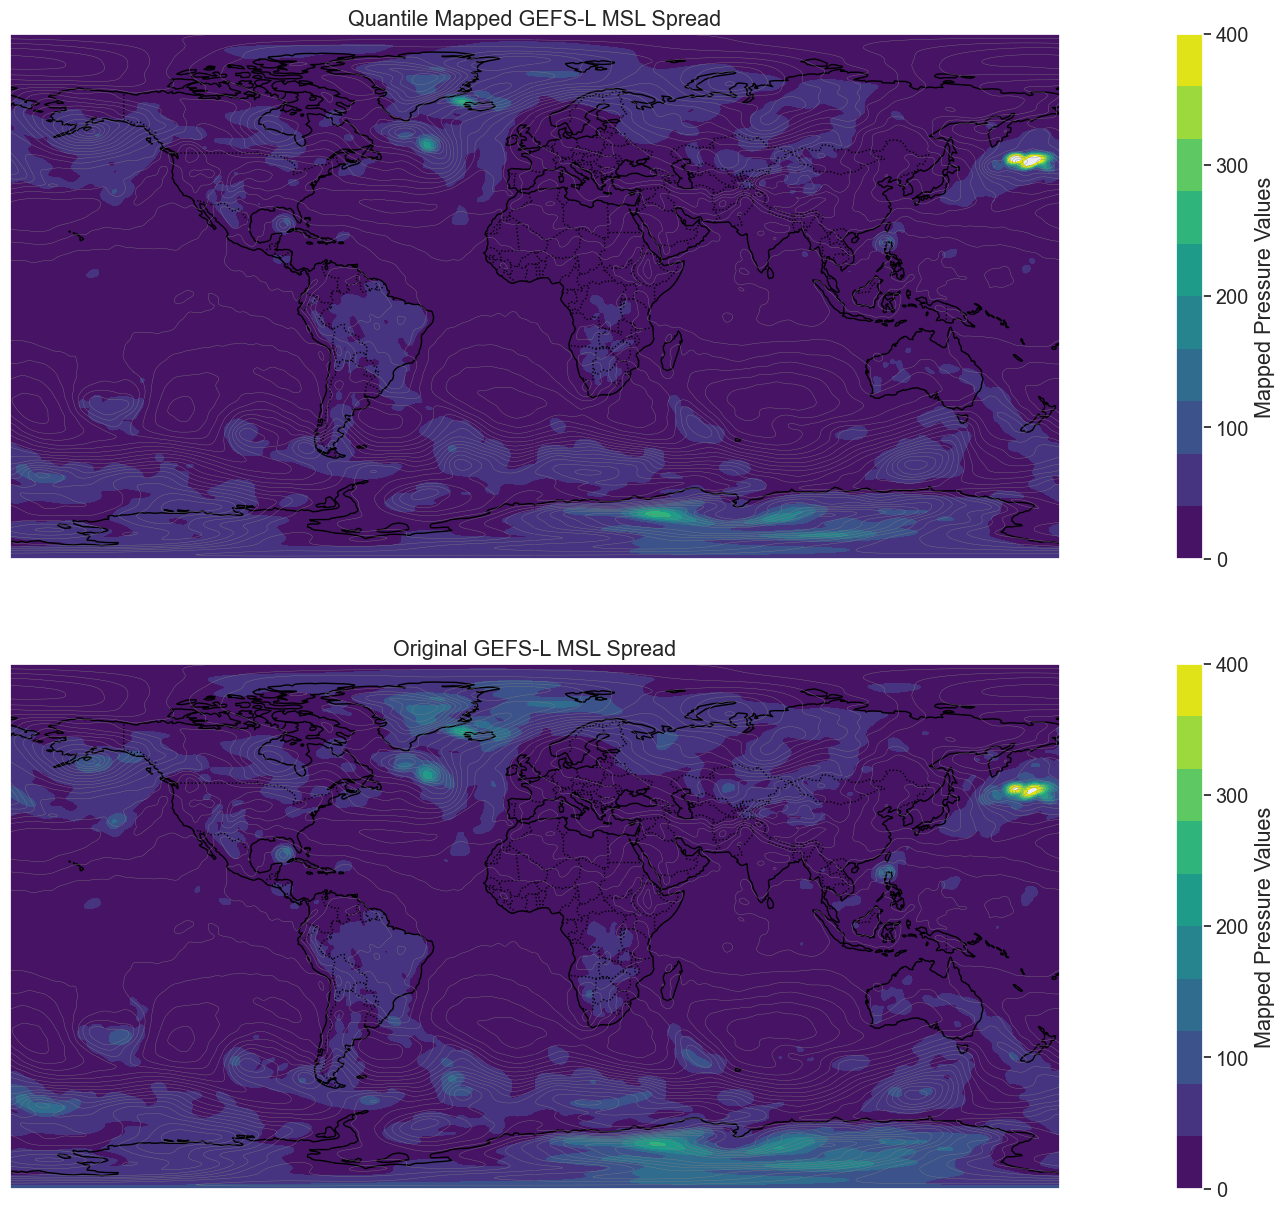

In [23]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Reshape the mapped data to the original shape
reshaped_data = mapped_gefs_l_data.reshape(gefs_l.gespr['prmsl'].shape)

# Create a figure and axis with Cartopy projection
fig, ax = plt.subplots(2,1,figsize=(30, 15), subplot_kw={'projection': ccrs.PlateCarree()})

# Add coastlines and borders for better visualization
ax[0].coastlines()
ax[0].add_feature(cfeature.BORDERS, linestyle=':')
# Add coastlines and borders for better visualization
ax[1].coastlines()
ax[1].add_feature(cfeature.BORDERS, linestyle=':')
# Plot the data
contour1 = ax[0].contourf(gefs_l.gespr['longitude'], 
gefs_l.gespr['latitude'], 
reshaped_data[0, :, :], 
transform=ccrs.PlateCarree(), 
cmap='viridis',
levels=np.linspace(0,400,11))

emean_contour = ax[0].contour(gefs_l.gespr['longitude'], 
gefs_l.gespr['latitude'], 
gefs_l.geavg['prmsl'].squeeze()/100, 
transform=ccrs.PlateCarree(), 
colors='gray', 
levels=np.arange(950,1050,4),linewidths=0.25)

ax[0].set_title('Quantile Mapped GEFS-L MSL Spread')
contour2 = ax[1].contourf(gefs_l.gespr['longitude'], 
gefs_l.gespr['latitude'], 
gefs_l.gespr['prmsl'].squeeze(), 
transform=ccrs.PlateCarree(), 
cmap='viridis',
levels=np.linspace(0,400,11)
)
emean_contour = ax[1].contour(gefs_l.gespr['longitude'], 
gefs_l.gespr['latitude'], 
gefs_l.geavg['prmsl'].squeeze()/100, 
transform=ccrs.PlateCarree(), 
colors='gray', 
levels=np.arange(950,1050,4),linewidths=0.25)
ax[1].set_title('Original GEFS-L MSL Spread')
# Add a colorbar
cbar1 = plt.colorbar(contour1, ax=ax[0], orientation='vertical', pad=0.05,ticks=[0,100,200,300,400])
cbar2 = plt.colorbar(contour2, ax=ax[1], orientation='vertical', pad=0.05,ticks=[0,100,200,300,400])

cbar1.set_label('Mapped Pressure Values')
cbar2.set_label('Mapped Pressure Values')
plt.show()

# PMM

In [4]:
variable = 'prmsl'
num_ensemble_members = len(gefs_l.ge_ens["number"])
sorted_ranked_ensemble_mean = np.argsort(
    gefs_l.ge_avg[variable].values.flatten()
)  # this is probably wrong


In [5]:
ensMean = gefs_l.ge_avg[variable].squeeze().values
ens = gefs_l.ge_ens[variable].squeeze().values
# Sets the sorted index array for each forecast hour's ensemble mean values low to high
ensMeanSort = np.array(np.argsort(ensMean.flatten()))

# Sets the index array of the sorted ensemble mean index array; in simple
# terms this can be used to rearrange the data back to its original order
ensMeanSortSort = np.array(np.argsort(ensMeanSort))

# Flattens the full ensemble by forecast hour
ensFlat = ens.flatten()

# Takes every 31st value to equal the size of the flattened mean array
ensFlat = np.array(ensFlat[0::31])

# Sets the sorted index array from low to high for each forecast hour
ensSort = np.array(np.argsort(ensFlat))

# Replaces the ensemble mean values with the ensemble values, then returns
# the values to the original index of the ensemble mean.
enspmm = np.array(
    ensFlat[ensSort][ensMeanSortSort]
)

# Catch for errors, haven't had an issue so this might be useless.
enspmm = enspmm.reshape((721,1440))

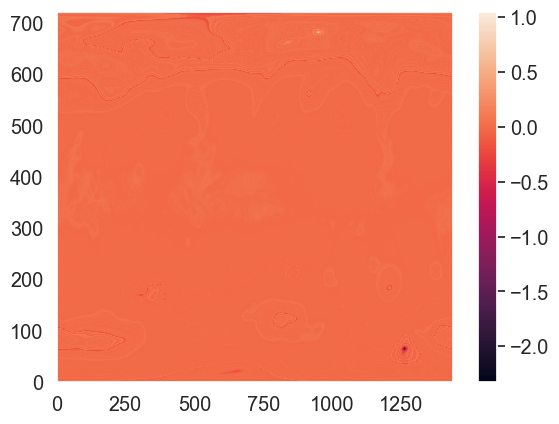

In [6]:
diff_map = (gefs_l.ge_avg['prmsl'].squeeze() - enspmm)/100
pcm = plt.pcolormesh(diff_map)
plt.colorbar(pcm)
plt.show()

In [ ]:
fig, axs = plt.subplots(3,1,figsize=(30, 20), subplot_kw={'projection': ccrs.PlateCarree()})
# Add coastlines and borders for better visualization
for i, ax in enumerate(axs):
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    if i == 0:
        pcm = ax.contourf(gefs_l.ge_spr['longitude'], 
        gefs_l.ge_spr['latitude'], 
        enspmm/100, 
        transform=ccrs.PlateCarree(),levels=np.linspace(950,1050,21)
        )
    elif i == 1: 
        pcm = ax.contourf(gefs_l.ge_spr['longitude'], 
        gefs_l.ge_spr['latitude'], 
        gefs_l.ge_avg['prmsl'].squeeze()/100, 
        transform=ccrs.PlateCarree(),levels=np.linspace(950,1050,21)
        )
    else:
        diff_map = (gefs_l.ge_avg['prmsl'].squeeze() - enspmm)/100
        pcm = ax.contourf(gefs_l.ge_spr['longitude'], 
        gefs_l.ge_spr['latitude'], 
        diff_map, 
        transform=ccrs.PlateCarree(),levels=np.linspace(-5,5,21)
        )        
    divider = make_axes_locatable(ax)
    ax_cb = divider.new_horizontal(size="5%", pad=0.1, axes_class=plt.Axes)
    fig.add_axes(ax_cb)
    plt.colorbar(pcm, cax=ax_cb)
plt.show()

KeyboardInterrupt: 